---
title: Linear Regression
jupyter: python3
---

## Introduction {#sec-05-top}

Regression analysis is a technique for investigating and modeling
the relationship between variables like X and Y. Here are some examples:

1. Within a country, we may wish to use per capita income (X) to estimate the 
   life expectancy (Y) of residents.
2. We may wish to use the size of a crab claw (X) to estimate the closing force 
   that it can exert (Y).
3. We may wish to use the height of a person (X) to estimate their weight (Y).

In all the above cases, we refer to $X$ as the *explanatory* or *independent*
variable. It is also sometimes referred to as a *predictor*. $Y$ is referred to as
the *response* or *dependent* variable. In this topic, we shall first introduce the
case of simple linear regression, where we model the $Y$ on a single $X$. In
later sections, we shall model the $Y$ on multiple $X$'s. This latter technique
is referred to as multiple linear regression.

Regression models are used for two primary purposes:

1. To understand how certain explanatory variables affect the response variable.
   This aim is typically known as *estimation*, since the primary focus is on 
   estimating the unknown parameters of the model.
2. To predict the response variable for new values of the explanatory variables.
   This is referred to as *prediction*.
   
In this topic, we shall focus on the estimation aim, since prediction models
require a paradigm of their own, and are best learnt alongside a larger suite
of models e.g. decision trees, support vector machines, etc. We shall cover
prediction in the topic of supervised learning @sec-08-top.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import folium
import geopandas
from itables import show

import statsmodels.api as sm
from statsmodels.formula.api import ols

from scipy import stats

::: {#exm-taiwan-reg-1 style="background-color: #D5D1D164; padding: 20px"}
### Taiwan real estate
\index{Taiwan Data!Description}

For this tutorial, we shall work with a data set from the 
[UCI machine learning repository](https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set).
It contains real estate prices in the Xindian district of Taiwan. Our goal is
to answer the following question:

> How well can we explain real-estate prices in Taiwan?

Here is a brief description of the columns in the dataset:

* `trans_date`: The date of the transaction. As you can see, this has been coded to be a numerical value, so 2013.5 refers to June 2013.
* `house_age`: Age of the house in years.
* `dist_MRT`: Distance the the nearest MRT (in metres)
* `num_stores`: Number of convenience stores within walking distance
* `lat`, `long`: Latitude and longitude
* `price`: House price per unit area (10,000 New Taiwan Dollars per Ping, which is about $3.3 m^2$)
* `X`, `Y`, `Xs`, `Ys`: Projected coordinates

In [2]:
re2 = pd.read_csv("data/taiwan_dataset.csv")
print(re2.head())

   id   trans_date  house_age   dist_MRT  num_stores       lat       long  \
0   1  2012.916667       32.0   84.87882          10  24.98298  121.54024   
1   2  2012.916667       19.5  306.59470           9  24.98034  121.53951   
2   3  2013.583333       13.3  561.98450           5  24.98746  121.54391   
3   4  2013.500000       13.3  561.98450           5  24.98746  121.54391   
4   5  2012.833333        5.0  390.56840           5  24.97937  121.54245   

   price              X             Y        Xs        Ys  
0   37.9  506501.554580  2.766295e+06  0.666075  1.559003  
1   42.2  506433.292007  2.766001e+06  0.597812  1.265025  
2   47.3  506862.973688  2.766798e+06  1.027494  2.062484  
3   54.8  506862.973688  2.766798e+06  1.027494  2.062484  
4   43.1  506732.307872  2.765899e+06  0.896828  1.163084  


::: {.content-visible when-format="pdf"}
Here is a scatter plot of the points in the dataset.

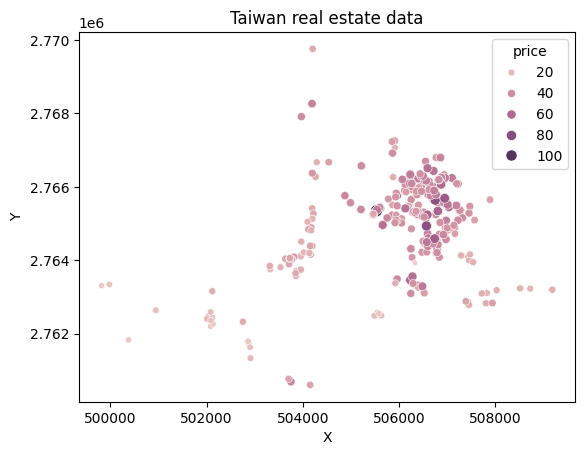

In [3]:
#| fig-align: center
ax = sns.scatterplot(data=re2, x='X', y='Y', hue='price', size='price')
ax.set_title("Taiwan real estate data");

:::


::: {.content-visible when-format="html"}
The following interactive map is available on the HTML version.

In [5]:
m = folium.Map(location=(45.5236, -122.6750))
df1 = geopandas.read_file('data/taiwan_dataset.csv')
gdf = geopandas.GeoDataFrame(
    re2, geometry=geopandas.points_from_xy(re2.X, re2.Y), crs="EPSG:3825"
)
gdf.explore("price", #tiles="CartoDB positron", 
            tooltip="price", marker_type="circle", 
            marker_kwds = {"radius": 50, "fill": True}, 
            legend_kwds = {"caption": "Price"})

:::

:::

Let us first explore the dataset with Python. How do this plots aid in your
understanding of the dataset?

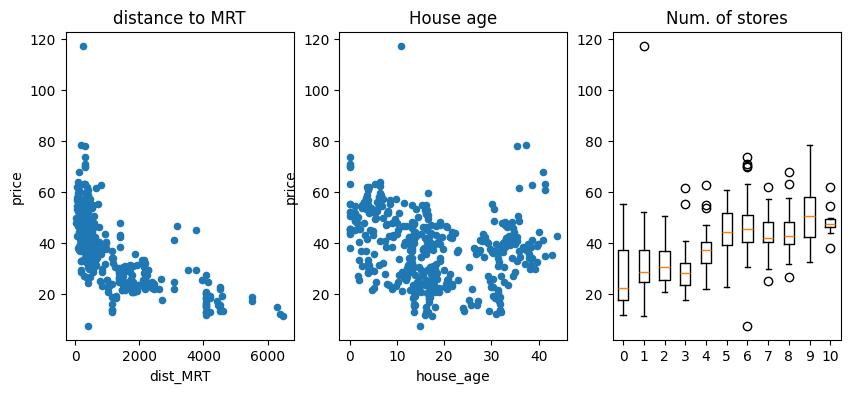

In [6]:
plt.figure(figsize=(10,4));
ax=plt.subplot(131)
re2.plot(x='dist_MRT', y='price', kind='scatter', ax=ax, title='distance to MRT')

ax=plt.subplot(132)
re2.plot(x='house_age', y='price', kind='scatter', ax=ax, title='House age')

ax= plt.subplot(133)
z = re2.num_stores.unique()
z.sort()
tmp2 = np.array([re2.price[re2.num_stores == x].to_numpy() for x in z], dtype=object)
ax.boxplot(tmp2, tick_labels=z); ax.set_title('Num. of stores');

## Simple Linear Regression

### Formal Set-up

The simple linear regression model is applicable when we have observations
$(X_i, Y_i)$ for $n$ individuals. For now, let's assume both the $X$ and $Y$ 
variables are quantitative.

The simple linear regression model is given by 

$$
Y_i = \beta_0 + \beta_1 X_i + e_i
$$
where 

* $\beta_0$ is intercept term, 
* $\beta_1$ is the slope, and 
* $e_i$ is an error term, specific to each individual in the dataset.

$\beta_0$ and $\beta_1$ are unknown constants that need to be estimated from the
data. There is an implicit assumption in the formulation of the model that there
is a linear relationship between $Y_i$ and $X_i$. In terms of distributions, we
assume that the $e_i$ are i.i.d Normal.

$$
e_i \sim N(0, \sigma^2), \; i =1\ldots, n
$$

The constant variance assumption is also referred to as homoscedascity (homo-skee-das-city). 
The validity of the above assumptions will have to be checked after the model is fitted.
All in all, the assumptions imply that:

1. $E(Y_i | X_i) = \beta_0 + \beta_1 X_i$, for $i=1, \ldots, n$.
2. $Var(Y_i | X_i) = Var(e_i) = \sigma^2$, for $i=1, \ldots, n$.
3. The $Y_i$ are independent.
4. The $Y_i$'s are Normally distributed.

### Estimation

Before deploying or using the model, we need to estimate optimal values to use 
for the unknown $\beta_0$ and $\beta_1$. We shall introduce the method of 
Ordinary Least Squares (OLS) for the estimation. Let us define the 
*error Sum of Squares* to be 

$$
SS_E = S(\beta_0, \beta_1) = \sum_{i=1}^n (Y_i - \beta_0 - \beta_1 X_i)^2
$$

Then the OLS estimates of $\beta_0$ and $\beta_1$ are given by 
$$
\mathop{\arg \min}_{\beta_0, \beta_1} \sum_{i=1}^n (Y_i - \beta_0 - \beta_1 X_i)^2
$$
The minimisation above can be carried out analytically, by taking partial 
derivative with respect to the two parameters and setting them to 0.

\begin{eqnarray*}
\frac{\partial S}{\partial \beta_0}  &=& -2 \sum_{i=1}^n (Y_i - \beta_0 - \beta_1 X_i) = 0 \\
\frac{\partial S}{\partial \beta_1}  &=& -2 \sum_{i=1}^n X_i (Y_i - \beta_0 - \beta_1 X_i) = 0 
\end{eqnarray*}

Solving and simplifying, we arrive at the following:

\begin{eqnarray*}
\hat{\beta_1} &=& \frac{\sum_{i=1}^n (X_i - \bar{X})(Y_i - \bar{Y})}{\sum_{i=1}^n (X_i - \bar{X})^2} \\
\hat{\beta_0} &=& \bar{Y} - \hat{\beta_0} \bar{X}
\end{eqnarray*} 
where $\bar{Y} = (1/n)\sum Y_i$ and $\bar{X} = (1/n)\sum X_i$.

If we define the following sums:

\begin{eqnarray*}
S_{XY} &=& \sum_{i=1}^n X_i Y_i - \frac{(\sum_{i=1}^n X_i )(\sum_{i=1}^n Y_i )}{n} \\
S_{XX} &=& \sum_{i=1}^n X_i^2 - \frac{(\sum_{i=1}^n X_i )^2}{n}
\end{eqnarray*}
then a form convenient for computation of $\hat{\beta_1}$ is 
$$
\hat{\beta_1} = \frac{S_{XY}}{S_{XX}}
$$

Once we have the estimates, we can use the estimated model to compute *fitted* values
for each observation, corresponding to our best guess of the mean of the
distributions from which the observations arose:
$$
\hat{Y_i} = \hat{\beta_0} + \hat{\beta_1} X_i, \quad i = 1, \ldots, n
$$
As always, we can form residuals as the deviations from fitted values. 
$$
r_i = Y_i - \hat{Y}_i
$$
Residuals are our best guess at the unobserved error terms $e_i$. Squaring the
residuals and summing over all observations, we can arrive at the following
decomposition, which is very similar to the one in the ANOVA model:

$$
\underbrace{\sum_{i=1}^n (Y_i  - \bar{Y})^2}_{SS_T} =  
\underbrace{\sum_{i=1}^n (Y_i  - \hat{Y_i})^2}_{SS_{Res}} +
\underbrace{\sum_{i=1}^n (\hat{Y_i}  - \bar{Y})^2}_{SS_{Reg}}
$$

where 

* $SS_T$ is known as the total sum of squares.
* $SS_{Res}$ is known as the residual sum of squares.
* $SS_{Reg}$ is known as the regression sum of squares.

In our model, recall that we had assumed equal variance for 
all our observations. We can estimate $\sigma^2$ with
$$
\hat{\sigma^2} = \frac{SS_{Res}}{n-2}
$$
Our distributional assumptions lead to the following for our estimates
$\hat{\beta_0}$ and $\hat{\beta_1}$:

\begin{eqnarray}
\hat{\beta_0} &\sim& N(\beta_0,\; \sigma^2(1/n + \bar{X}^2/S_{XX})) \\
\hat{\beta_1} &\sim& N(\beta_1,\; \sigma^2/S_{XX})
\end{eqnarray}

The above are used to construct confidence intervals for $\beta_0$ and $\beta_1$,
based on $t$-distributions.

### Hypothesis Test for Model Significance

The first test that we introduce here is to test if the coefficient $\beta_1$ is
significantly different from 0. It is essentially a test of whether it was 
worthwhile to use a simple linear regression, instead of a 
simple mean to represent the data.

The null and alternative hypotheses are:

\begin{eqnarray*}
H_0 &:& \beta_1 = 0\\
H_1 &:& \beta_1 \ne 0
\end{eqnarray*}

The test statistic is 

$$
F_0 = \frac{SS_{Reg}/1}{SS_{Res}/(n-2)}
$$ 

Under the null hypothesis, $F_0 \sim F_{1,n-2}$. 

It is also possible to perform this same test as a $t$-test, using the result earlier.
The statement of the hypotheses is equivalent to the $F$-test. The test statistic
$$
T_0 = \frac{\hat{\beta_1}}{\sqrt{\hat{\sigma^2}/S_{XX}}}
$$ 
Under $H_0$, the distribution of $T_0$ is $t_{n-2}$. This $t$-test and the earlier 
$F$-test in this section are *identical*. It can be proved that $F_0 = T_0^2$; the 
obtained $p$-values will be identical.

### Coefficient of Determination, $R^2$

The coefficient of determination $R^2$ is defined as

$$
R^2 = 1 - \frac{SS_{Res}}{SS_T} = \frac{SS_{Reg}}{SS_T}
$$
It can be interpreted as the proportion of variation in $Yi$, explained by 
the inclusion of $X_i$. Since $0 \le SS_{Res} \le SS_T$, we can easily prove that 
$0 \le R^2 \le 1$.  The larger the value of $R^2$ is, the better the model is.

When we get to the case of multiple linear regression, take note that simply 
including more variables in the model will increase $R^2$. This is undesirable; it 
is preferable to have a parsimonious model that explains the response variable well.

::: {#exm-taiwan-reg-2 style="background-color: #D5D1D164; padding: 20px"}
### Price vs. house age
\index{Taiwan Data!Simple linear, price vs. house}

As a first model, we fit price ($Y$) against house age ($X_1$). From the plot
above, we already suspect this may not be ideal, but let us use it as a
starting point.

In [7]:
lm_house_age_1 = ols('price ~ house_age', data=re2).fit()
print(lm_house_age_1.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     19.11
Date:                Sun, 24 May 2026   Prob (F-statistic):           1.56e-05
Time:                        16:48:04   Log-Likelihood:                -1658.3
No. Observations:                 414   AIC:                             3321.
Df Residuals:                     412   BIC:                             3329.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     42.4347      1.211     35.042      0.0

From the output, we can tell that the *estimated* model for Price ($Y$) against
Housing age ($X_1$) is:

$$
Y = 42.43 - 0.25 X_1
$$


The estimates are $\hat{\beta_0} = 42.43$ and $\hat{\beta_1} = -0.25$. The
output includes the 95% confidence intervals for $\beta_0$ and $\beta_1$. The
$R^2$ is 0.044, which means that means that only 4.4% of the variation in $Y$
is explained by $X$. This is extremely poor, even though the $p$-value for the
$F$-test is very small (0.000016).


A simple interpretation of the model is as follows:

> For every 1 year increase in house age, there is an average associated *decrease* in
> price of $0.25 \times 10,000$ New Taiwan Dollars.

:::

::: {.callout-warning}
Note that this interpretation has to be taken very cautiously, especially when there are
other explanatory variables in the model.
:::

::: {#exm-taiwan-reg-3 style="background-color: #D5D1D164; padding: 20px"}
### Price vs. house age estimated line
\index{Taiwan Data!Price vs. house, estimated line}

In linear regression, we almost always wish to use the model to understand what
the mean of future observations would be. In this case, we may wish to use the
model to understand how the Price changes as house age increases. This is
because, based on our formulation,

$$
E(Y | X) = \beta_0 + \beta_1 X
$$

After estimating the parameters, we would have:
$$
\widehat{E(Y | X)} = \hat{\beta_0} + \hat{\beta_1} X
$$

Thus we can vary the values of $X$ to study how the mean of $Y$ changes. Here 
is how we can do so for the model that we have just fit.

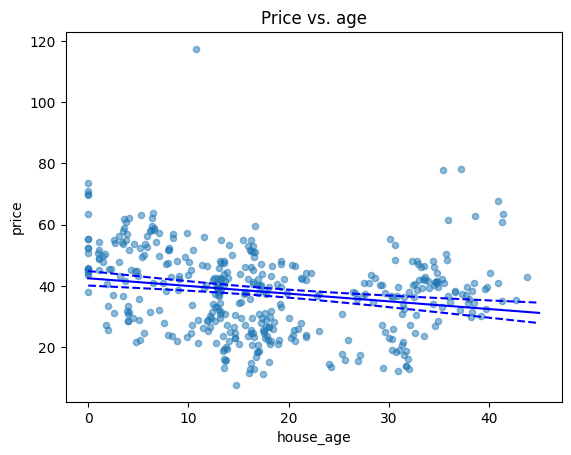

In [8]:
#| fig-align: center

new_df = sm.add_constant(pd.DataFrame({'house_age' : np.linspace(0, 45, 100)}))
predictions_out = lm_house_age_1.get_prediction(new_df)

ax = re2.plot(x='house_age', y='price', kind='scatter', alpha=0.5 )
ax.set_title('Price vs. age');
ax.plot(new_df.house_age, predictions_out.conf_int()[:, 0].reshape(-1), 
        color='blue', linestyle='dashed');
ax.plot(new_df.house_age, predictions_out.conf_int()[:, 1].reshape(-1), 
        color='blue', linestyle='dashed');
ax.plot(new_df.house_age, predictions_out.predicted, color='blue');

:::

## Multiple Linear Regression

### Formal Setup

When we have more than 1 explanatory variable, we turn to multiple linear
regression - a more general version of what we have been dealing with so far.
We still assume that we have observed information from $n$ individuals, but for
each one, we now observe a vector of values:

$$
Y_i, \, X_{1,i},  \, X_{2,i}, \ldots, \, X_{p-1,i},  X_{p,i}
$$

In other words, we observe $p$ independent variables and 1 response variable for 
each individual in our dataset. The analogous equation to the earlier model is

$$
Y_i = \beta_0 + \beta_1 X_{1,i} + \cdots + \beta_p  X_{p,i} + e
$$

It is easier to write things with matrices for multiple linear regression:

$$
\textbf{Y} = \begin{bmatrix}
Y_1 \\
Y_2 \\
\vdots \\
Y_n
\end{bmatrix}, \;
\textbf{X} = \begin{bmatrix}
1 & X_{1,1} & X_{2,1} & \cdots &X_{p,1}\\
1 & X_{1,2} & X_{2,2} & \cdots &X_{p,2}\\
\vdots & \vdots & \vdots & {} & \vdots \\
1 & X_{1,n} & X_{2,n} & \cdots &X_{p,n}\\
\end{bmatrix}, \;
\boldsymbol{ \beta } = \begin{bmatrix}
\beta_0 \\
\beta_1 \\
\vdots \\
\beta_p
\end{bmatrix}, \;
\boldsymbol{e} = \begin{bmatrix}
e_1 \\
e_2 \\
\vdots \\
e_n 
\end{bmatrix}
$$

With the above matrices, we can re-write the regression model as 
$$
\textbf{Y} = \textbf{X} \boldsymbol{\beta} + \textbf{e}
$$
We retain the same distributional assumptions as in simple linear regression.

### Estimation 

Similar to estimation in the earlier case, we can define $SS_E$ to be 
$$
SS_E = S(\beta_0, \beta_1,\ldots,\beta_p) = \sum_{i=1}^n (Y_i - \beta_0 - 
\beta_1 X_{1,i} - \cdots - \beta_p X_{p,i} )^2
$$

Minimising the above cost function leads to the OLS estimates:
$$
\hat{\boldsymbol{\beta}} =  (\textbf{X}'\textbf{X})^{-1} \textbf{X}'\textbf{Y} 
$$
The fitted values can be computed with
$$
\hat{\textbf{Y}} = \textbf{X} \hat{\boldsymbol{\beta}} =
\textbf{X} (\textbf{X}'\textbf{X})^{-1} \textbf{X}'\textbf{Y} 
$$
Residuals are obtained as 
$$
\textbf{r} = \textbf{Y} - \hat{\textbf{Y}}
$$
Finally, we estimate $\sigma^2$ using 
$$
\hat{\sigma^2} = \frac{SS_{Res}}{n-p} = \frac{\textbf{r}' \textbf{r}}{n-p}
$$

### Adjusted $R^2$

In the case of multiple linear regression, $R^2$ is calculated exactly as in
simple linear regression, and its interpretation remains the same:
$$
R^2 = 1 - \frac{SS_{Res}}{SS_T}
$$

However, note that $R^2$ can be inflated simply by adding more terms to the
model (even insignificant terms). Thus, we use the adjusted $R^2$, which penalizes 
us for adding more and more terms to the model:
$$
R^2_{adj} = 1 - \frac{SS_{Res}/(n-p)}{SS_T/(n-1)}
$$

### Hypothesis Tests

The $F$-test in the multiple linear regression helps determine if our regression
model provides any advantage over the simple mean model. The null and
alternative hypotheses are:

\begin{eqnarray*}
H_0 &:& \beta_1 = \beta_2 = \cdots = \beta_p = 0\\
H_1 &:& \beta_j \ne 0 \text{ for at least one } j \in \{1, 2, \ldots, p\}
\end{eqnarray*}

The test statistic is 

$$
F_1 = \frac{SS_{Reg}/p}{SS_{Res}/(n-p-1)}
$$

Under the null hypothesis, $F_0 \sim F_{p,n-p-1}$. 

It is also possible to test for the significance of individual $\beta$ terms, using 
a $t$-test. The output is typically given for all the coefficients in a table.
The statement of the hypotheses pertaining to these tests is:

\begin{eqnarray*}
H_0 &:& \beta_j = 0\\
H_1 &:& \beta_j \ne 0 
\end{eqnarray*}

However, note that these $t$-tests are partial because it should be interpreted
as a test of the contribution of $\beta_j$, *given that all other terms are already in the model*.

::: {#exm-taiwan-reg-4 style="background-color: #D5D1D164; padding: 20px"}
### Price vs. house age and distance to MRT
\index{Taiwan Data!Price vs. house and distance}

For our first example on multiple linear regression, let us regress price ($Y$)
on house age ($X_1$) and distance to MRT ($X_2$).

In [9]:
lm_age_mrt_1 = ols('price ~ house_age + dist_MRT', data=re2).fit()
print(lm_age_mrt_1.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.489
Method:                 Least Squares   F-statistic:                     198.3
Date:                Sun, 24 May 2026   Prob (F-statistic):           5.07e-61
Time:                        16:48:12   Log-Likelihood:                -1527.9
No. Observations:                 414   AIC:                             3062.
Df Residuals:                     411   BIC:                             3074.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     49.8856      0.968     51.547      0.0

The estimated equation for the model is 

$$
Y = 49.89 - 0.23 X_1 - 0.0072 X_2
$$

At 5%-level, the estimates for both $\beta_1$ and $\beta_2$ are significantly
different from 0. Moreover, the adjusted $R^2$ is now a more respectable 0.49. 
:::

<br/>

::: {#exm-taiwan-reg-5 style="background-color: #D5D1D164; padding: 20px"}
### Broken line regression
\index{Taiwan Data!Broken line regression}

Although multiple linear regression is usually carried out with distinct
variables, it is possible to include functions of the same variable. Suppose we
define:

* $X_1$: House age
* $X_2$: Distance to MRT
* $X_3$ to be as follows:

$$
X_3 = 
\begin{cases}
0 & \text{ if } X_1 \le 25, \\
X_1 - 25 &\text{ if } X_1 > 25
\end{cases}
$$

This allows a non-linear function of house age to be included in the model. It
is similar to including a polynomial term, but this is simpler to interpret.

In [10]:
re2['x3'] = [(x - 25) if x > 25 else 0 for x in re2.house_age]

lm_age_mrt_2 = ols('price ~ house_age + x3 + dist_MRT', data=re2).fit()
print(lm_age_mrt_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.527
Model:                            OLS   Adj. R-squared:                  0.523
Method:                 Least Squares   F-statistic:                     152.0
Date:                Sun, 24 May 2026   Prob (F-statistic):           3.24e-66
Time:                        16:48:15   Log-Likelihood:                -1512.9
No. Observations:                 414   AIC:                             3034.
Df Residuals:                     410   BIC:                             3050.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     52.9935      1.090     48.598      0.0

We've managed to improve the adjusted $R^2$ by a little, but let's focus on
understanding the estimated relationship. To help us out, let's fix the
distance-to-MRT to be two values: 300m, and 1500m. Roughly speaking, these
values correspond to the 1st and 3rd quartiles of the distance values. For a
given distance value, we then have two sub-cases:

1. House age less than or equal to 25 years, and
2. House age more than 25 years.

The full equation is as follows:

$$
Y = 53.00 - 0.60 X_1 - 0.0065 X_2 + 1.16 X_3
$$ 

The special cases correspond to:

1. $X_2 = 300$: 
   1. $X_1 <= 25$:
      * $Y = 51.05 - 0.60 X_1$
   2. $X_1 > 25$:
      * $Y = 22.05 + 0.56 X_1$
2. $X_2 = 1500$:
   1. $X_1 <= 25$:
      * $Y = 43.25 - 0.60 X_1$
   2. $X_1 > 25$:
      * $Y = 14.25 + 0.56 X_1$

Visually, here is what the estimated lines look like:

In [11]:
new_df = sm.add_constant(pd.DataFrame({'house_age' : np.linspace(0, 45, 100)}))
new_df['x3'] = [(x - 25) if x > 25 else 0 for x in new_df.house_age]
new_df2 = new_df.copy()

new_df['dist_MRT'] = 300
new_df2['dist_MRT'] = 1500

predictions_out = lm_age_mrt_2.get_prediction(new_df)
predictions_out2 = lm_age_mrt_2.get_prediction(new_df2)

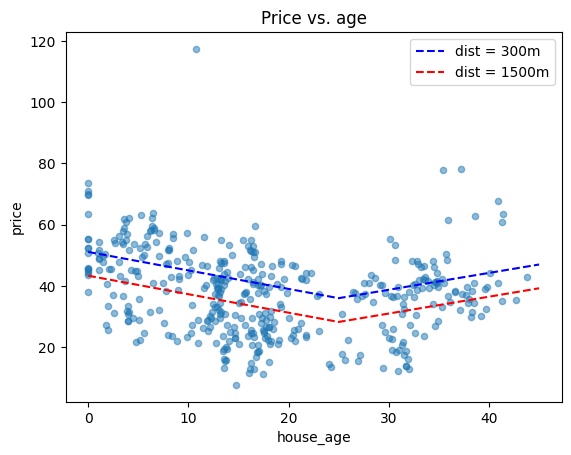

In [12]:
#| fig-align: center
ax = re2.plot(x='house_age', y='price', kind='scatter', alpha=0.5 )
ax.set_title('Price vs. age');
ax.plot(new_df.house_age, predictions_out.predicted_mean, 
        color='blue', linestyle='dashed', label='dist = 300m');
ax.plot(new_df2.house_age, predictions_out2.predicted_mean, 
        color='red', linestyle='dashed', label='dist = 1500m');
ax.legend();

:::

## Including a Categorical Variable

The explanatory variables in a linear regression model do not need to be continuous.
Categorical variables can also be included in the model. In order to include them,
they have to be coded using dummy variables. 

For instance, suppose that we wish to include gender in a model as $X_3$. There 
are only two possible genders in our dataset: Female and Male. We can represent
$X_3$ as an indicator variable, with

$$
X_{3,i} = 
\begin{cases}
1 & \text{individual $i$ is male}\\
0 & \text{individual $i$ is female}
\end{cases}
$$

The model (without subscripts for the $n$ individuals) is then:
$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + e
$$
For females, the value of $X_3$ is 0. Hence the model reduces to
$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + e
$$
On the other hand, for males, the model reduces to 
$$
Y = (\beta_0 + \beta_3) + \beta_1 X_1 + \beta_2 X_2 + e
$$
The difference between the two models is in the intercept. The other 
coefficients remain the same. 

In general, if the categorical variable has $a$ levels, we will need $a-1$
columns of indicator variables to represent it. This is in contrast to machine
learning models which use one-hot encoding. The latter encoding results in
columns that are linearly dependent if we include an intercept term in the
model.

::: {#exm-taiwan-reg-6 style="background-color: #D5D1D164; padding: 20px"}
### Price vs. num stores and distance to MRT
\index{Taiwan Data!Number of stores, categorical}

For this example, let us work with a reduced model in order to understand how
things work. Price will remain the dependent variable, but we shall use
distance to MRT (quantitative) and number of nearby convenience stores.
However, we shall recode the number of stores as low (or high) corresponding to
whether or not there were 4 stores or less (resp. more than 5).

In [14]:
re2['num_stores_cat'] = ['low' if x <= 4 else 'high' for x in re2.num_stores]

lm_cat_1 = ols('price ~ dist_MRT + num_stores_cat', re2).fit()
print(lm_cat_1.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.502
Model:                            OLS   Adj. R-squared:                  0.500
Method:                 Least Squares   F-statistic:                     207.3
Date:                Sun, 24 May 2026   Prob (F-statistic):           5.54e-63
Time:                        16:48:32   Log-Likelihood:                -1523.3
No. Observations:                 414   AIC:                             3053.
Df Residuals:                     411   BIC:                             3065.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                47.80

The categorical variable has been coded (by Python) as follows:

$$
X_4 = 
\begin{cases}
1, & \text{if there were 4 nearby stores or less} \\
0, & \text{otherwise}
\end{cases}
$$

As a result, we have estimated two models:

* Corresponding to a large number of nearby stores: $Y = 47.81 - 0.0055 X_2$
* Corresponding to a small number of nearby stores: $Y = 40.40 - 0.0055 X_2$

:::

### Including an Interaction Term

A more complex model arises from an interaction between two terms. Here, we shall
consider an interaction between a continuous variable and a categorical 
explanatory variable. Suppose that we have three predictors: height ($X_1$),
weight ($X_2$) and gender ($X_3$). As spelt out in the previous section, we should use 
indicator variables to represent $X_3$ in the model. 

If we were to include an *interaction* between gender and weight, we would  be
allowing for a males and females to have separate coefficients for $X_2$. Here is
what the model would appear as:
$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \beta_4 X_2 X_3 + e
$$
Remember that $X_3$ will be 1 for males and 0 for females. The simplified 
equation for males would be:

$$
Y = (\beta_0 + \beta_3) + \beta_1 X_1 + (\beta_2 + \beta_4) X_2 + e
$$
For females, it would be:
$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + e
$$

Both the intercept and coefficient of $X_2$ are different, for each value of
$X_3$. Recall that in the previous section, only the intercept term was
different.

::: {#exm-taiwan-reg-7 style="background-color: #D5D1D164; padding: 20px"}
### Interaction between num of stores and distance to MRT
\index{Taiwan Data!Interaction term}

In an earlier model, we fitted the number of stores and distance to MRT to the
model. Here, we include an interaction term.

In [15]:
lm_cat_2 = ols('price ~ dist_MRT * num_stores_cat', re2).fit()
print(lm_cat_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.538
Model:                            OLS   Adj. R-squared:                  0.534
Method:                 Least Squares   F-statistic:                     158.9
Date:                Sun, 24 May 2026   Prob (F-statistic):           2.54e-68
Time:                        16:48:33   Log-Likelihood:                -1508.0
No. Observations:                 414   AIC:                             3024.
Df Residuals:                     410   BIC:                             3040.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

Notice that we now have the largest adjusted $R^2$ out of all of the models we have fit so far.

The model that we have fit consists of two models:

1. For the case that the number of stores is 4 or less: $Y = 39.88 - 0.005 X_2$
2. For the case that the number of stores is more than 4: $Y = 54.84 - 0.028 X_2$.

:::

::: {.callout-note}
Can you interpret the result above based on your intuition or understanding of real estate prices?
:::


## Residual Analysis

Recall from earlier that residuals are computed as 
$$
r_i = Y_i - \hat{Y_i}
$$
Residual analysis is a standard approach for identifying how we can improve a
model. In the case of linear regression, we can use the residuals to assess if
the distributional assumptions hold. We can also use residuals to identify
influential points that are masking the general trend of other points. Finally,
residuals can provided some direction on how to improve the model.

### Standardised Residuals

It can be shown that the variance of the residuals is in fact not constant! Let us 
define the hat-matrix as 
$$
\textbf{H} = \textbf{X}(\textbf{X}'\textbf{X} )^{-1} \textbf{X}'
$$
The diagonal values of $\textbf{H}$ will be denoted $h_{ii}$, for $i = 1, \ldots, n$. 
It can then be shown that 
$$
Var(r_i) = \sigma^2 (1 - h_{ii}), \quad Cov(r_i, r_j) = -\sigma^2 h_{ij}
$$
As such, we use the standardised residuals when checking if the assumption of Normality
has been met.

$$
r_{i,std}  = \frac{r_i}{\hat{\sigma}\sqrt{1 - h_{ii}}}
$$
If the model fits well, standardised residuals should look similar to a $N(0,1)$
distribution. In addition, large values of the standardised residual indicate
potential outlier points.

By the way, $h_{ii}$ is also referred to as the *leverage* of a point. It is a
measure of the potential influence of a point (on the parameters, and future
predictions). $h_{ii}$ is a value between 0 and 1. For a model with $p$
parameters, the average $h_{ii}$ should be should be $p/n$. We consider points
for whom $h_{ii} > 2 \times p/n$ to be high leverage points.

In the literature and in textbooks, you will see mention of residuals, standardised 
residuals and studentised residuals. While they differ in definitions slightly, they
typically yield the same information. Hence we shall stick to standardised residuals
for our course.

::: {#exm-taiwan-reg-8 style="background-color: #D5D1D164; padding: 20px"}
### Normality check for `lm_age_mrt_1`
\index{Taiwan Data!Normality check}

One of the first checks for Normality is to create a histogram. If the
residuals adhere to a Normal distribution, we should observe a symmetric
bell-shaped distribution.

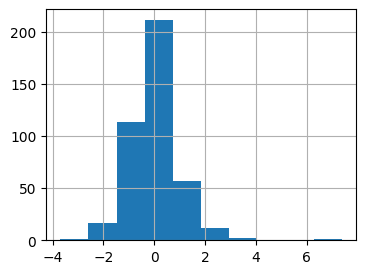

In [16]:
#| fig-align: center
plt.figure(figsize=(4,3))
r_s = pd.Series(lm_age_mrt_1.resid_pearson)
r_s.hist();

From above, it appears that the distribution is slightly skewed, and there is
one noticeable outlier. A second graphical diagnostic plot that we make is a
QQ-plot. 

A QQ-plot plots the standardized sample quantiles against the theoretical
quantiles of a N(0; 1) distribution. If they fall on a straight line, then we
would say that there is evidence that the data came from a normal distribution.

Especially for unimodal datasets, the points in the middle will fall close to the 
line. The value of a QQ-plot is in judging if the tails of the data are fatter 
or thinner than the tails of the Normal. 

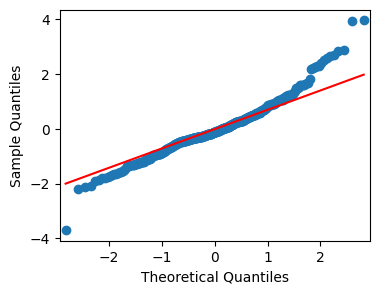

In [17]:
#| fig-align: center
fig = sm.qqplot(r_s[r_s < 6], line="q")
fig.set_size_inches(4,3);

:::

Overall, the residuals do indicate a lack of Normal behaviour. Non-normality in
the residuals should lead us to view the hypothesis tests with caution. The
estimated models are still valid, in the sense that they are optimal.
Estimation of the models did not require the assumption of Normality. So far,
we have only focused on inspecting the $R^2$ to assess the model quality.

### Scatterplots

To understand the model fit better, a set of scatterplots are typically made. These
are plots of standardised residuals (on the $y$-axis) against

* fitted values 
* explanatory variables, one at a time.
* potential variables.

Residuals are meant to contain only the information that our model cannot explain.
Hence, if the model is good, the residuals should only contain random noise. There 
should be no apparent pattern to them. If we find such a pattern in one of the above
plots, we would have some clue as to how we could improve the model.

We typically inspect the plots for the following patterns:

![Residuals](figs/regression_residuals.png){width=80%}


1. A pattern like the one on the extreme left is ideal. Residuals are 
   randomly distributed around zero; there is no pattern or trend in the 
   plot.
2. The second plot is something rarely seen. It would probably appear if we 
   were to plot residuals against a *new* variable that is not currently in the 
   model. If we observe this plot, we should then include this variable in the model.
3. This plot indicates we should include a quadratic term in the model.
4. The wedge shape (or funnel shape) indicates that we do not have 
   homoscedascity. The solution to this is either a transformation of the response,
   or weighted least squares. You will cover these in your linear models class.
   

::: {#exm-taiwan-reg-9 style="background-color: #D5D1D164; padding: 20px"}
### Example: Residual Plots for `lm_age_mrt_2`
\index{Taiwan Data!Residual scatterplots}

Let us extract and create the residual plots for the second model that we had fit, earlier.

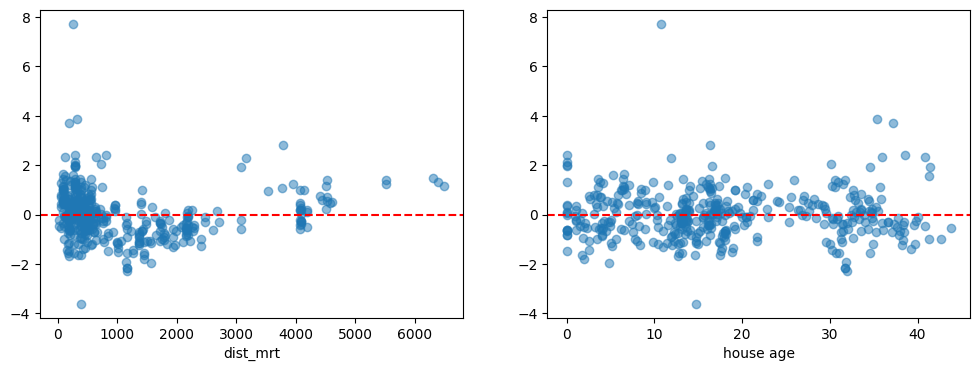

In [18]:
#| fig-align: center
plt.figure(figsize=(12,4));
r_s = lm_age_mrt_2.resid_pearson
ax=plt.subplot(121)
ax.scatter(re2.dist_MRT, r_s, alpha=0.5)
ax.set_xlabel('dist_mrt')
ax.axhline(y=0, color='red', linestyle='--')

ax=plt.subplot(122)
ax.scatter(re2.house_age, r_s, alpha=0.5)
ax.set_xlabel('house age');
ax.axhline(y=0, color='red', linestyle='--');

While the plot for house age looks acceptable (points are evenly scattered
about the red dashed line), the one for distance shows some curvature. This is
something we can try to fix, using a transformation of the x-variable.

:::

### Influential Points

The influence of a point on the inference can be judged by how much the inference
changes with and without the point. For instance to assess if point $i$ is 
influential on coefficient $j$:

1.  Estimate the model coefficients with all the data points.
2.  Leave out the observations $(Y_i , X_i)$ one at a time and re-estimate 
    the model coefficients.
3.  Compare the $\beta$'s from step 2 with the original estimate from step 1.

While the above method assesses influence on parameter estimates, Cook's distance
performs a similar iteration to assess the influence on the fitted values. Cook's
distance values greater than 1 indicate possibly influential points.

There are several ways to deal with influential points. First, we can remove
the influential point (or sets of points) and asssess how much the model
changes. Based on our understanding of the domain, we can then decide to keep
or remove those points. A second approach is to create a dummy variable that
identifies those points (individually).  Fitting the subsequent model allows
all points to be used in estimating standard errors, but quantifies an
adjustment for those points. A third approach is to use a *robust linear
model*. This is a model that automatically reduces the influence of aberrant
points. This is a good topic to know about - do read up on it if you are keen!

::: {#exm-taiwan-reg-10 style="background-color: #D5D1D164; padding: 20px"}
### Example: Influential Points for `lm_age_mrt_2` 
\index{Taiwan Data!Influential points}

The influence of a point on the inference can be judged by how much the inference
changes with and without the point. For instance to assess if point $i$ is 
influential on coefficient $j$:

1.  Estimate the model coefficients with all the data points.
2.  Leave out the observations $(Y_i , X_i)$ one at a time and re-estimate 
    the model coefficients.
3.  Compare the $\beta$'s from step 2 with the original estimate from step 1.

While the above method assesses influence on parameter estimates, Cook's distance
performs a similar iteration to assess the influence on the fitted values. Cook's
distance values greater than 1 indicate possibly influential points.

In [19]:
infl = lm_age_mrt_2.get_influence()
infl_df = infl.summary_frame()

In [20]:
print(infl_df.head())

   dfb_Intercept  dfb_house_age    dfb_x3  dfb_dist_MRT   cooks_d  \
0       0.004477      -0.015423  0.004746      0.015011  0.000249   
1      -0.004122       0.022294 -0.024375     -0.017434  0.000236   
2       0.016558       0.009214 -0.017881     -0.018001  0.000405   
3       0.037359       0.020789 -0.040346     -0.040616  0.002054   
4      -0.037629       0.024643 -0.013610      0.006609  0.000375   

   standard_resid  hat_diag  dffits_internal  student_resid    dffits  
0       -0.350312  0.008050        -0.031558      -0.349937 -0.031524  
1        0.319229  0.009195         0.030754       0.318879  0.030720  
2        0.638887  0.003955         0.040257       0.638426  0.040228  
3        1.438604  0.003955         0.090648       1.440488  0.090767  
4       -0.463313  0.006946        -0.038748      -0.462869 -0.038711  


:::

## Transformation

::: {#exm-taiwan-reg-11 style="background-color: #D5D1D164; padding: 20px"}
### Log-transformation
\index{Taiwan Data!Log transformation}

As we observed in the residual plots, the distance-to-MRT variable displays a
slight curvature. We can fix this by taking a log-transformation of the
variable before fitting the model.

Below, we include the code to perform this fitting.

In [21]:
re2['ldist'] = np.log(re2.dist_MRT)

lm_age_mrt_3 = ols('price ~ house_age + x3 + num_stores + ldist', data=re2).fit()
print(lm_age_mrt_3.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.597
Model:                            OLS   Adj. R-squared:                  0.593
Method:                 Least Squares   F-statistic:                     151.6
Date:                Sun, 24 May 2026   Prob (F-statistic):           2.07e-79
Time:                        16:48:50   Log-Likelihood:                -1479.4
No. Observations:                 414   AIC:                             2969.
Df Residuals:                     409   BIC:                             2989.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     84.0709      4.009     20.971      0.0

:::

Now, take some to investigate the following issues:

1. Interpret the coefficient for `dist_MRT`.
2. Have the issues with the residuals been fixed?
3. What is the difference between how this model uses `num_stores`, and how `lm_cat_1` uses it?
4. How did we choose 25 as the breakpoint for house-age? Is it the ideal one?

## Summary, Further topics

Linear regression is a very flexible model. It is quick to fit, easily
generalisable and much more interpretable than other models. These are some of
the reasons why it is still one of the most widely used models in industry. 

In our short session, we have touched on several practical tips for using
regression models. However, take note that regression models can be generalised
in many other ways. Here are some models you may want to read up on:

* Assuming correlated errors instead of independent error terms
* Using splines to include non-linear functions of explanatory variables.
* Kernel regression is an even more modern method for including higher-order
  terms, but at this point we start to lose interpretability
* Constrained regression, when we know certain coefficients should be positive, for instance.
* Robust linear models to automagically take care of wild outliers.

Good reference textbooks for this topic are @draper1998applied and
@hastie2009introduction.

## References

### Website References

1. [Taiwan dataset from UCI machine learning repository](https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set)
3. [Stats models documentation](https://www.statsmodels.org/stable/regression.html)
6. [Diagnostics](https://www.zeileis.org/teaching/AER/Ch-Validation-handout.pdf)
6. [On residual plots](https://online.stat.psu.edu/stat462/node/120/)